<a href="https://colab.research.google.com/github/frankguo77/NTU2025Fall/blob/main/on-policy-rl/03.actor-critic-td.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm /content/NTU2025Fall -rf
!git clone https://github.com/frankguo77/NTU2025Fall.git

Cloning into 'NTU2025Fall'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 112 (delta 37), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 13.39 MiB | 14.14 MiB/s, done.
Resolving deltas: 100% (37/37), done.


In [2]:
import sys
sys.path.append("/content/NTU2025Fall/on-policy-rl")

In [3]:
!pip install swig
!pip install gymnasium[box2d]
!pip install pyvirtualdisplay

In [4]:
import numpy as np
import torch
import torch.optim as optim
from collections import deque
import time
from tqdm import tqdm

# Import our RL utilities
from rl_utils import (
    set_seeds,
    ActorCriticNetwork,
    create_env_with_wrappers,
    plot_training_results,
    plot_variance_analysis,
)

# Create configuration
CONFIG = {
    "seed": 42,
    "episodes": 5000,
    "gamma": 0.99,
    "lr": 5e-4,
    "device": "cpu",
    "window_length": 100,
    "target_score": 200,  # LunarLander-v3 target score
    # Environment: LunarLander-v3 only
    "env_id": "LunarLander-v3",
    "env_kwargs": {
        "gravity": -10.0,
        "enable_wind": False,
        "wind_power": 15.0,
        "turbulence_power": 1.5,
    },
    # Video Recording Config
    "record_videos": True,
    "video_folder": "videos",
    "num_videos": 9,  # Number of videos to record during training
    "record_test_videos": True,
    # Neural Network Config
    "network": {
        "fc_out_features": [64, 64], # Shared features
        "actor_features": [32],  # Actor-specific layers after shared
        "critic_features": [32],  # Critic-specific layers after shared
        "activation": "SiLU",
        "use_layer_norm": True,
        "dropout_rate": 0.0,
    },
    # Actor-Critic Specific Parameters
    "critic_loss_coeff": 0.5,  # Weight for critic loss in total loss
    # TD-Specific Parameters
    "n_steps": 5,  # N-step TD parameter
    "max_grad_norm": 0.5,  # Maximum gradient norm for clipping
}

set_seeds(CONFIG["seed"])
print(f"🎲 Global random seeds set to {CONFIG['seed']} for reproducible results")
print(
    f"📝 Environment episodes will use seeds {CONFIG['seed']} + episode_number for varied but reproducible episodes"
)

🎲 Global random seeds set to 42 for reproducible results
📝 Environment episodes will use seeds 42 + episode_number for varied but reproducible episodes


In [5]:
class ActorCriticTDAgent:
  def __init__(self, network, config):
    self.network = network.to(config["device"])
    self.optimizer = optim.Adam(self.network.parameters(), lr=config["lr"])
    self.gamma = config["gamma"]
    self.device = config["device"]
    self.window_size = config.get("window_length")
    self.n_steps = config["n_steps"]
    self.max_grad_norm = config["max_grad_norm"]

    # Actor-Critic specific parameters
    self.critic_loss_coeff = config.get("critic_loss_coeff")

    # Print detailed network information including parameter count
    print(f"📊 ACTOR-CRITIC TD NETWORK DETAILS:")
    self.network.print_network_info()
    print(f"🎯 N-Steps: {self.n_steps}")
    print(f"🎓 Learning Rate: {config['lr']} (shared for actor & critic)")
    print(f"⚖️ Critic Loss Coefficient: {self.critic_loss_coeff}")
    print(f"✂️ Max Gradient Norm: {self.max_grad_norm}")

    # N-step buffer storage
    self.reset_buffers()

    # Gradient tracking for variance analysis
    self.gradient_norms = []
    self.episode_scores = []  # Raw undiscounted episode scores
    # self.episode_returns = []  # Discounted episode returns (G_0)
    self.score_variance_history = []
    # self.return_variance_history = []

    # # Advantage tracking for analysis
    # self.advantages = []
    # self.baselines_used = []  # Track which baseline was used

    # Update step tracking - separate from episode numbers
    self.update_step = 0
    self.update_steps_history = []

    self.loss_history = {
        "actor_loss": [],  # Policy loss
        "critic_loss": [],  # Value function loss
        "total_loss": [],  # Combined loss
    }

    # Advantage normalization fallback tracking
    self.advantage_norm_stats = {
        "total_actor_updates": 0,
        "fallback_normalizations": 0,
    }

    # Gradient clipping tracking with history
    self.gradient_clip_fraction_history = []  # Add history tracking
    self.gradient_clip_stats = {
        "total_updates": 0,
        "clipped_updates": 0,
    }

  def reset_buffers(self):
    """Reset N-step buffers for new episode."""
    self.log_probs = []
    self.rewards = []
    self.values = []  # Store value predictions
    self.states = []  # Store states for value function training
    self.actions = []
    self.episode_score = 0.0

  def store_reward(self, reward):
    """Store reward in buffer."""
    self.rewards.append(reward)
    self.episode_score += reward

  def should_update(self, done):
    """Check if we should perform an update."""
    return len(self.rewards) >= self.n_steps or done

  def select_action(self, state):
    """Select an action from the policy distribution."""
    # Normalize observation before feeding to network

    state = torch.as_tensor(state, dtype=torch.float32, device=self.device)
    dist, value = self.network(state)
    action = dist.sample()

    if self.network.is_continuous:
      log_prob = dist.log_prob(action)
      # Use the policy network's clip_action method for proper bounds
      action_to_env = self.network.clip_action(action).flatten()
    else:
      log_prob = dist.log_prob(action)
      action_to_env = action.item()

    self.log_probs.append(log_prob)
    self.values.append(value)
    self.states.append(state)
    self.actions.append(action)

    return action_to_env

  def update_policy(self, next_state=None, done=False):
    """Update the policy network using the collected episode data."""
    if not self.log_probs:
      return {"actor_loss": 0.0, "ctritic_loss": 0.0, "total_loss": 0.0}, 0.0

    # Increment update step counter
    self.update_step += 1
    self.advantage_norm_stats["total_actor_updates"] += 1
    self.gradient_clip_stats["total_updates"] += 1

    # Calculate N-step TD targets
    td_targets = [0] * len(self.rewards)
    # td_targets = []

    # Get bootstrap value for the last state
    if done:
        bootstrap_value = 0.0  # Terminal state has value 0
    else:
        # `torch.no_grad()` is used when computing the bootstrap value because it
        # serves as a fixed target for the current update - we don't want gradients
        # flowing back through the bootstrap value V(s_{t+1}) since it would create
        # circular dependencies where the network's predictions affect their own
        # training targets.
        with torch.no_grad():
            next_state_tensor = torch.as_tensor(next_state, dtype=torch.float32, device=self.device)
            _, bootstrap_value = self.network(next_state_tensor)
            bootstrap_value = bootstrap_value.item()

    # Calculate N-step returns
    discounted_return = bootstrap_value
    for i in range(len(self.rewards) - 1, -1, -1):
      discounted_return = self.rewards[i] + self.gamma * discounted_return
      td_targets[i] = discounted_return

    # # Calculate N-step returns
    # for i in range(len(self.rewards)):
    #     td_target = 0.0
    #     discount = 1.0

    #     # Sum discounted rewards for available steps
    #     for j in range(i, len(self.rewards)):
    #         td_target += discount * self.rewards[j]
    #         discount *= self.gamma

    #     # Add bootstrapped value if not terminal
    #     if not done or i < len(self.rewards) - 1:
    #         td_target += discount * bootstrap_value

    #     td_targets.append(td_target)

    # Convert to tensors
    td_targets = torch.tensor(td_targets, dtype=torch.float32, device=self.device)
    values_tensor = torch.stack(self.values)
    log_probs_tensor = torch.stack(self.log_probs)

    # Calculate advantages (no normalization of TD targets for critic!)
    advantages = td_targets - values_tensor.detach()

    # Robust advantage normalization: only check for NaN after normalization
    advantages_mean = advantages.mean()
    if advantages.shape[0] < 2:
      advantages_std = torch.tensor(0, dtype=torch.float32, device=self.device)
    else:
      advantages_std = advantages.std()

    # Normalize advantages, fallback to centering if NaN occurs
    advantages_normalized = (advantages - advantages_mean) / (advantages_std + 1e-8)
    if torch.isnan(advantages_normalized).any():
        self.advantage_norm_stats["fallback_normalizations"] += 1
        advantages_normalized = advantages - advantages_mean

    actor_loss = -(log_probs_tensor * advantages_normalized).mean()

    # Critic loss (no normalization of targets!)
    critic_loss = torch.nn.functional.mse_loss(values_tensor, td_targets)

    # Total loss
    total_loss =  actor_loss + self.critic_loss_coeff * critic_loss
    # total_loss =  10 * actor_loss + 1e-5 * critic_loss

    # Update network with gradient clipping
    self.optimizer.zero_grad()
    total_loss.backward()

    # Calculate gradient norm before clipping/updating
    total_grad_norm = 0.0
    for param in self.network.parameters():
      if param.grad is not None:
        param_norm = param.grad.data.norm(2)
        total_grad_norm += param_norm ** 2

    total_grad_norm = total_grad_norm ** 0.5
    self.gradient_norms.append(total_grad_norm)

    # Apply gradient clipping and track if clipping occurred
    gradient_clipped = total_grad_norm > self.max_grad_norm
    if gradient_clipped:
        self.gradient_clip_stats["clipped_updates"] += 1

    # Store gradient clipping fraction for this update
    self.gradient_clip_fraction_history.append(float(gradient_clipped))

    torch.nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)

    self.optimizer.step()

    # 6. Log losses
    actor_loss_value = actor_loss.item()
    critic_loss_value = critic_loss.item()
    total_loss_value = total_loss.item() # For REINFORCE, total == policy
    self.loss_history["actor_loss"].append(actor_loss_value)
    self.loss_history["critic_loss"].append(critic_loss_value)
    self.loss_history["total_loss"].append(total_loss_value)
    self.update_steps_history.append(self.update_step)

    if done:
      # Episode ended, store episode score and reset completely
      self.episode_scores.append(self.episode_score)

      # Track score variance over recent episodes
      if len(self.episode_scores) >= self.window_size:
        recent_scores = self.episode_scores[-self.window_size:]
        score_variance = np.var(recent_scores)
        self.score_variance_history.append(score_variance)

    self.reset_buffers()

    return {
        "actor_loss": actor_loss_value,
        "critic_loss": critic_loss_value,
        "total_loss": total_loss_value,
    }, total_grad_norm

  def get_variance_stats(self):
      """Get variance statistics for analysis - all calculated from last N episodes."""
      if len(self.episode_scores) < 2:
          return {
              "gradient_norm_mean": 0.0,
              "gradient_norm_std": 0.0,
              "score_mean": 0.0,
              "score_std": 0.0,
              "recent_score_variance": 0.0,
              "gradient_cv": 0.0,
              "score_cv": 0.0,
          }

      # Calculate ALL statistics from the SAME window (last N episodes)
      final_window_size = min(self.window_size, len(self.episode_scores))
      recent_scores = self.episode_scores[-final_window_size:]
      recent_gradients = self.gradient_norms[-final_window_size:] if len(self.gradient_norms) >= final_window_size else self.gradient_norms

      # Calculate means and standard deviations
      gradient_mean = np.mean(recent_gradients) if recent_gradients else 0.0
      gradient_std = np.std(recent_gradients) if len(recent_gradients) > 1 else 0.0
      score_mean = np.mean(recent_scores)
      score_std = np.std(recent_scores)

      # Calculate Coefficient of Variation (CV = std / mean)
      gradient_cv = gradient_std / gradient_mean if gradient_mean > 0 else 0.0
      score_cv = score_std / score_mean if score_mean != 0 else 0.0

      return {
          "gradient_norm_mean": gradient_mean,
          "gradient_norm_std": gradient_std,
          "score_mean": score_mean,
          "score_std": score_std,
          "recent_score_variance": np.var(recent_scores),
          "gradient_cv": gradient_cv,
          "score_cv": score_cv,
      }

  def get_advantage_normalization_stats(self):
      """Get fallback normalization statistics."""
      stats = self.advantage_norm_stats.copy()

      # Calculate fallback rate
      if stats["total_actor_updates"] > 0:
          fallback_rate = stats["fallback_normalizations"] / stats["total_actor_updates"]
          stats["fallback_rate_percent"] = fallback_rate * 100.0
      else:
          stats["fallback_rate_percent"] = 0.0

      return stats

  def get_gradient_clip_stats(self):
      """Get gradient clipping statistics with windowed analysis."""
      stats = self.gradient_clip_stats.copy()

      # Calculate clipping rate
      if stats["total_updates"] > 0:
          clip_rate = stats["clipped_updates"] / stats["total_updates"]
          stats["clip_rate_percent"] = clip_rate * 100.0
      else:
          stats["clip_rate_percent"] = 0.0

      # Add windowed statistics
      if hasattr(self, 'window_size') and len(self.gradient_clip_fraction_history) > 0:
          window_size = min(self.window_size, len(self.gradient_clip_fraction_history))
          recent_clip_fractions = self.gradient_clip_fraction_history[-window_size:]
          stats["windowed_clip_rate_percent"] = np.mean(recent_clip_fractions) * 100.0
      else:
          stats["windowed_clip_rate_percent"] = 0.0

      return stats


In [8]:
def train_actor_critic_td(is_continuous, config):
    """Main training loop for the Actor-Critic TD agent."""
    action_type = "Continuous" if is_continuous else "Discrete"
    print(f"\n{'='*70}")
    print(f"ACTOR-CRITIC TD ({action_type.upper()})")
    print(f"{'='*70}")

    # Calculate video recording interval
    video_record_interval = max(1, config["episodes"] // config["num_videos"])
    print(f"📹 Recording {config['num_videos']} videos every {video_record_interval} episodes")

    # Create algorithm-specific video folder
    video_folder = f"/content/videos/ActorCritic_TD_{action_type.lower()}"
    config_with_videos = config.copy()
    config_with_videos["video_folder"] = video_folder
    config_with_videos["video_record_interval"] = video_record_interval

    # Create Environment (this will automatically clean up existing videos)
    env = create_env_with_wrappers(
        config_with_videos,
        is_continuous,
        record_videos=True,
        video_prefix=f"ac_td_{action_type.lower()}",
        cleanup_existing=True
    )

    # Get observation dimension and space
    dummy_obs, _ = env.reset()
    observation_dim = len(dummy_obs)

    # Create Actor-Critic Network and Agent
    print(f"\n🏗️ CREATING {action_type.upper()} ACTOR-CRITIC NETWORK:")
    network = ActorCriticNetwork(
        observation_dim=observation_dim,
        action_space=env.action_space,
        is_continuous=is_continuous,
        network_config=config["network"]
    )

    print(f"\n🤖 INITIALIZING {action_type.upper()} ACTOR-CRITIC AGENT:")
    agent = ActorCriticTDAgent(network, config)

    # Training Loop
    scores = []
    scores_window = deque(maxlen=config["window_length"])
    start_time = time.time()

    print(f"\n🚀 STARTING {action_type.upper()} TRAINING...")

    # Use tqdm for progress bar with detailed information
    pbar = tqdm(range(1, config["episodes"] + 1), desc="Training", unit="episode")

    for i_episode in pbar:
      state, _ = env.reset(seed=config["seed"] + i_episode)

      ep_reward = 0
      while True:
          action = agent.select_action(state)

          next_state, reward, terminated, truncated, info = env.step(action)
          done = terminated or truncated

          agent.store_reward(reward)
          # agent.rewards.append(reward)
          ep_reward += reward

          # Check if we should update
          if agent.should_update(done):
              loss_dict, grad_norm = agent.update_policy(next_state, done)

          state = next_state

          if done:
            break

      scores.append(ep_reward)
      scores_window.append(ep_reward)

      # loss_dict, grad_norm = agent.update_policy()

      # Get latest loss values (may be 0.0 if no update occurred this episode)
      if agent.loss_history["actor_loss"]:
          actor_loss = agent.loss_history["actor_loss"][-1]
          critic_loss = agent.loss_history["critic_loss"][-1]
          total_loss = agent.loss_history["total_loss"][-1]
      else:
          actor_loss = critic_loss = total_loss = 0.0

      # Get latest gradient norm
      latest_grad_norm = agent.gradient_norms[-1] if agent.gradient_norms else 0.0

      # Get advantage normalization fallback rate
      adv_stats = agent.get_advantage_normalization_stats()
      failure_rate = adv_stats.get("fallback_rate_percent", 0.0)

      # Get advantage normalization fallback rate
      adv_stats = agent.get_advantage_normalization_stats()
      failure_rate = adv_stats.get("fallback_rate_percent", 0.0)

      # Get gradient clipping rate
      grad_clip_stats = agent.get_gradient_clip_stats()
      grad_clip_rate = grad_clip_stats.get("windowed_clip_rate_percent", 0.0)

      # Update tqdm description with current statistics
      avg_score_window = np.mean(scores_window) if len(scores_window) > 0 else 0.0

      pbar.set_description(
          f"Ep {i_episode:4d} | "
          f"Score: {ep_reward:6.1f} | "
          f"AvgScore({config['window_length']}): {avg_score_window:6.1f} | "
          f"Updates: {agent.update_step:4d} | "
          f"ActorLoss: {actor_loss:7.4f} | "
          f"CriticLoss: {critic_loss:7.4f} | "
          f"GradNorm: {latest_grad_norm:6.4f} | "
          f"GradClip%: {grad_clip_rate:4.1f} | "
          f"AdvFail: {failure_rate:4.1f}%"
      )

      if avg_score_window > 250:
        print(f"\n🎉 Early stopped at avg sccore: {avg_score_window}.")
        break

      # Handle video display - show all videos collected so far
      # if i_episode % video_record_interval == 0 and config["record_videos"]:
      #     from rl_utils.environment import display_latest_video
      #     pbar.write(f"\nVideo recorded at episode {i_episode}")
      #     display_latest_video(
      #         config_with_videos["video_folder"],
      #         f"reinforce_{action_type.lower()}",
      #         i_episode
      #     )

    pbar.close()
    env.close()

    elapsed_time = time.time() - start_time
    # Use config window size for final performance calculation
    final_window_size = min(config["window_length"], len(scores))
    final_performance = np.mean(scores[-final_window_size:]) if final_window_size > 0 else 0.0

    # Print advantage normalization statistics
    adv_stats = agent.get_advantage_normalization_stats()
    print(f"\n{action_type} training completed in {elapsed_time:.1f} seconds!")

    return scores, agent.loss_history, agent

In [9]:
# --- DISCRETE ACTION SPACE: VALUE FUNCTION BASELINE ---
print("Starting Actor-Critic TD training with DISCRETE actions...")

discrete_value_scores, discrete_value_losses, discrete_value_agent = train_actor_critic_td(
    is_continuous=False,
    config=CONFIG,
)

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/videos/ActorCritic_TD_discrete folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Starting Actor-Critic TD training with DISCRETE actions...

ACTOR-CRITIC TD (DISCRETE)
📹 Recording 9 videos every 555 episodes

🏗️ CREATING DISCRETE ACTOR-CRITIC NETWORK:

🤖 INITIALIZING DISCRETE ACTOR-CRITIC AGENT:
📊 ACTOR-CRITIC TD NETWORK DETAILS:
ActorCriticNetwork (Discrete) initialized with 9,445 trainable parameters.
  Shared features:     4,992 parameters
  Actor branch:        2,276 parameters
    - Actor FC layers: 2,144 parameters
    - Actor head:      132 parameters
  Critic branch:       2,177 parameters
    - Critic FC layers:2,144 parameters
    - Critic head:     33 parameters
Action space: 4 discrete actions
🎯 N-Steps: 5
🎓 Learning Rate: 0.0005 (shared for actor & critic)
⚖️ Critic Loss Coefficient: 0.5
✂️ Max Gradient Norm: 0.5

🚀 STARTING DISCRETE TRAINING...


Ep 5000 | Score:  249.4 | AvgScore(100):  242.7 | Updates: 326894 | ActorLoss: -0.0000 | CriticLoss: 9823.7998 | GradNorm: 2869.8108 | GradClip%: 100.0 | AdvFail:  0.0%: 100%|██████████| 5000/5000 [1:39:48<00:00,  1.20s/episode]


Discrete training completed in 5988.7 seconds!


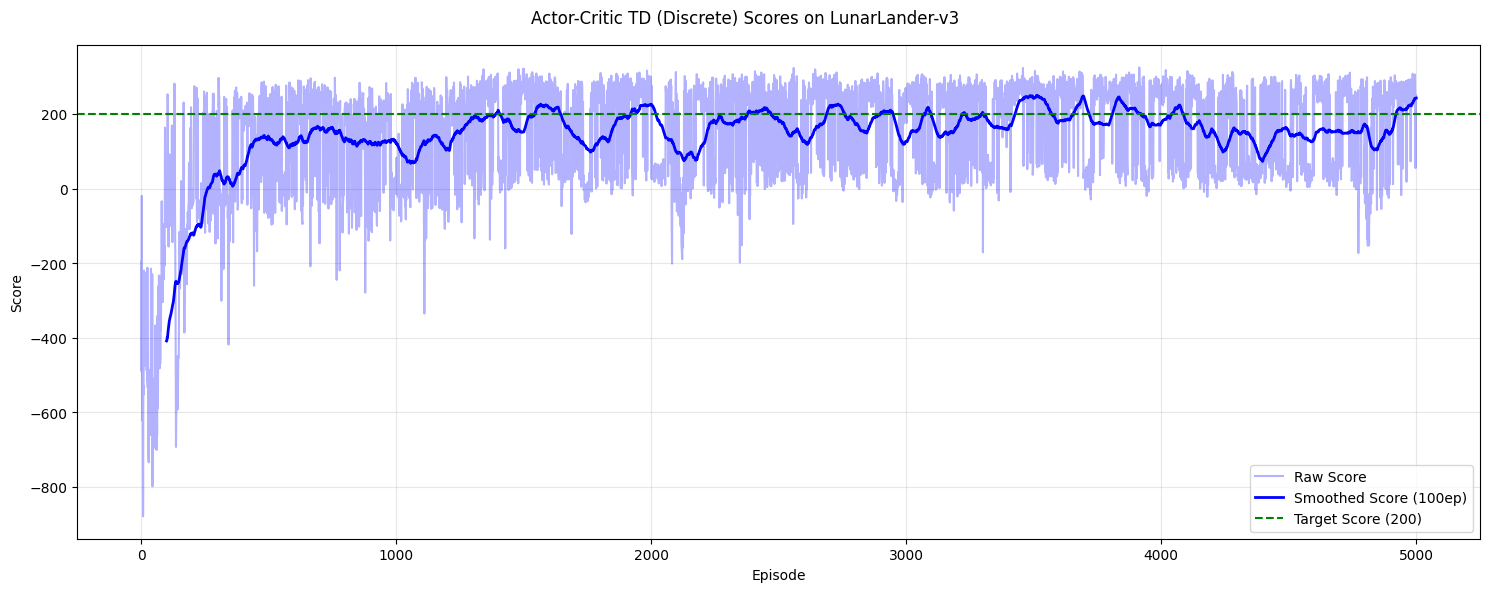

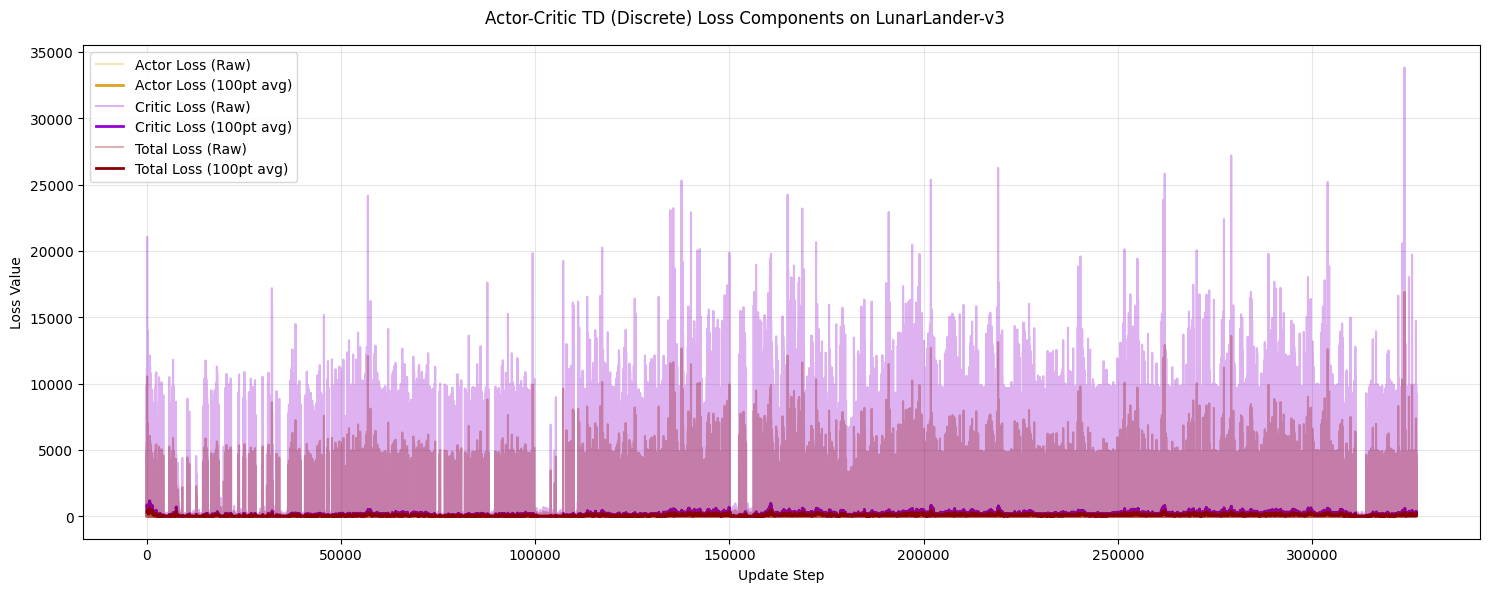

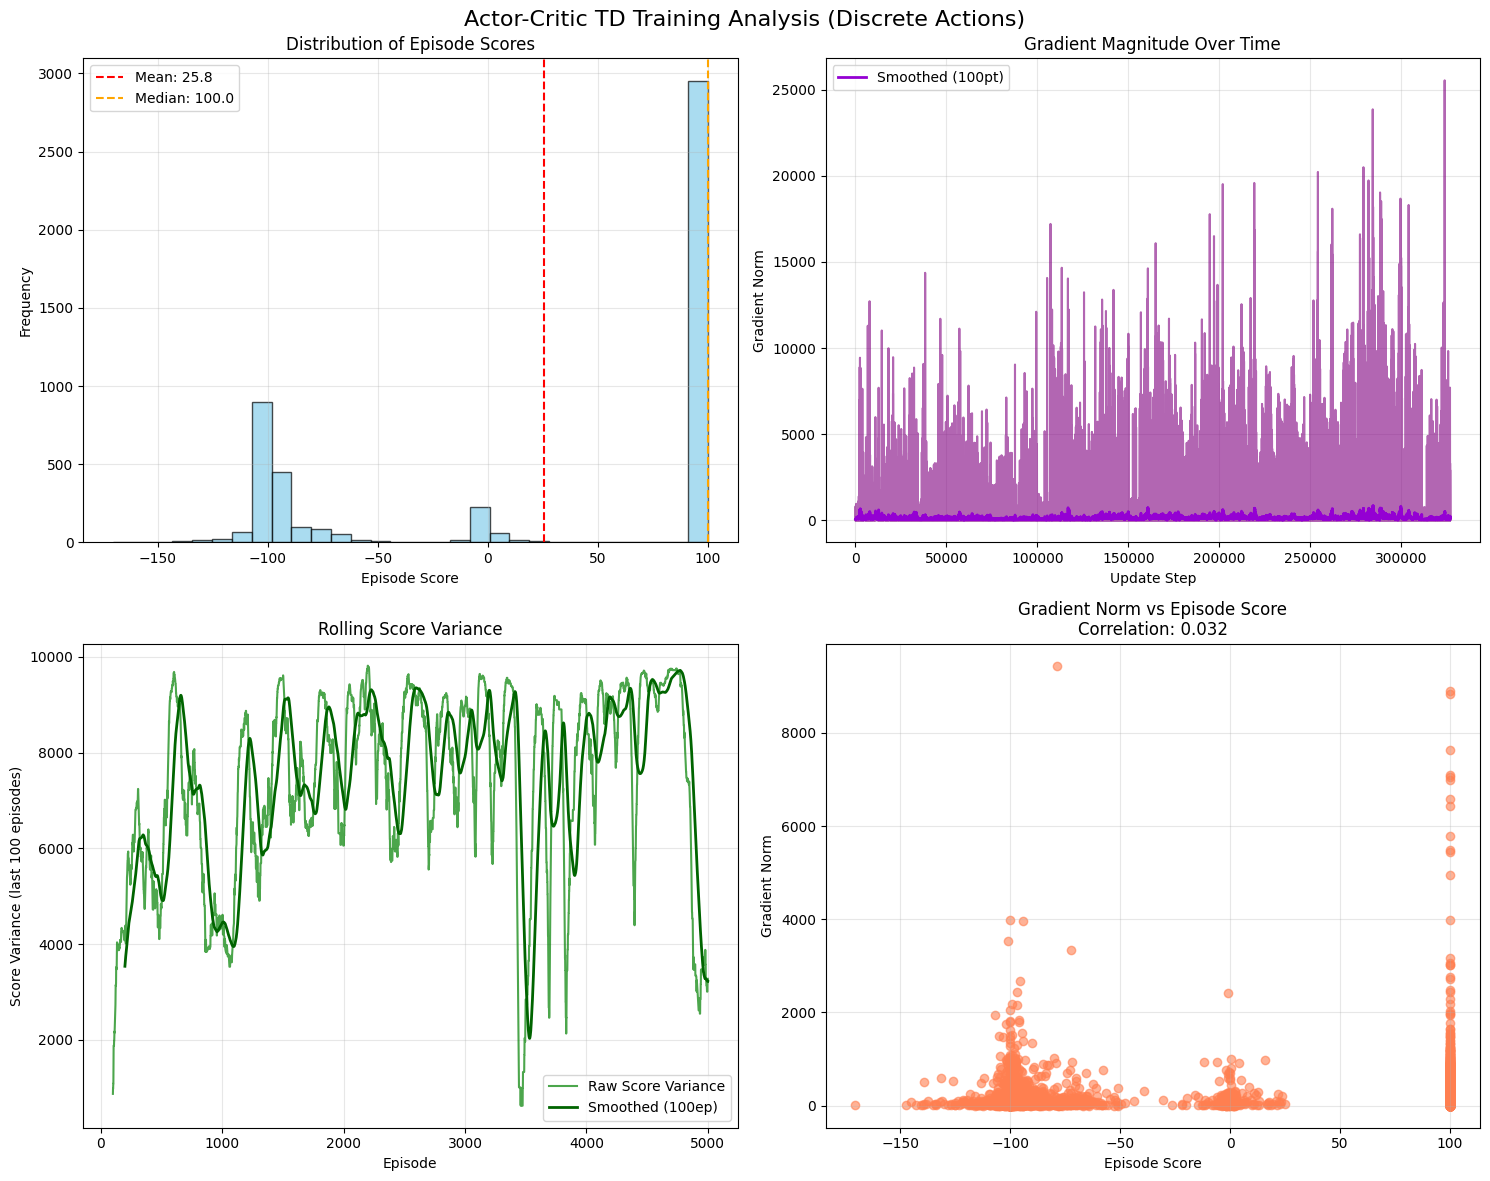

In [10]:
# Plot results for discrete global average baseline
plot_training_results(
    discrete_value_scores,
    discrete_value_losses,
    CONFIG,
    "Discrete",
    algorithm_name="Actor-Critic TD"
)

# Show variance analysis
plot_variance_analysis(
    discrete_value_agent,
    discrete_value_scores,
    "Discrete",
    CONFIG,
    algorithm_name="Actor-Critic TD"
)

# Training completion message
final_window_size = min(CONFIG["window_length"], len(discrete_value_scores))
final_avg = np.mean(discrete_value_scores[-final_window_size:]) if final_window_size > 0 else 0.0

In [ ]:
import os, glob
pattern = os.path.join("/content/videos/REINFORCE_discrete/", f"reinforce_discrete-episode-*.mp4")
video_files = glob.glob(pattern)
print(f"📹 {len(video_files)} training videos available ")

📹 9 training videos available 


288.63213441005473
276.45138315745635
301.1016731188479
296.616649665328
263.5852362996428


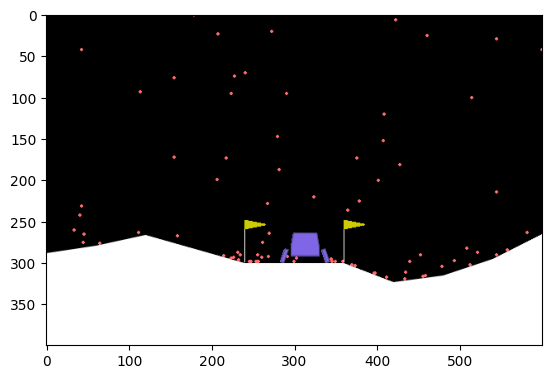

In [11]:
# fix(env, seed)
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('LunarLander-v3', render_mode="rgb_array")
discrete_value_agent.network.eval()  # set the network into evaluation mode
NUM_OF_TEST = 5 # Do not revise this !!!
test_total_reward = []
action_list = []
for i in range(NUM_OF_TEST):
  actions = []
  state,_ = env.reset()

  img = plt.imshow(env.render())

  total_reward = 0

  done = False
  truncated = False
  while not (done or truncated):
    with torch.no_grad():
      action  = discrete_value_agent.select_action(state)
      actions.append(action)
      state, reward, done, truncated, _ = env.step(action)

      total_reward += reward

      # img.set_data(env.render())
      # display.display(plt.gcf())
      # display.clear_output(wait=True)

  print(total_reward)
  img = plt.imshow(env.render())
  # display.display(plt.gcf())
  test_total_reward.append(total_reward)

  action_list.append(actions) # save the result of testing
